In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# ── Style global ──────────────────────────────────────────────────
PALETTE_TARGET = {'Dropout': '#E63946', 'Graduate': '#2A9D8F', 'Enrolled': '#F4A261'}
PALETTE_BINARY = ['#E63946', '#2A9D8F']

sns.set_theme(style='whitegrid', palette='muted', font='DejaVu Sans')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.facecolor': 'white'
})


In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
predict_students_dropout_and_academic_success = fetch_ucirepo(id=697) 
  
# data (as pandas dataframes) 
X = predict_students_dropout_and_academic_success.data.features 
y = predict_students_dropout_and_academic_success.data.targets 
  
# metadata 
print(predict_students_dropout_and_academic_success.metadata) 
  
# variable information 
print(predict_students_dropout_and_academic_success.variables) 


{'uci_id': 697, 'name': "Predict Students' Dropout and Academic Success", 'repository_url': 'https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success', 'data_url': 'https://archive.ics.uci.edu/static/public/697/data.csv', 'abstract': "A dataset created from a higher education institution (acquired from several disjoint databases) related to students enrolled in different undergraduate degrees, such as agronomy, design, education, nursing, journalism, management, social service, and technologies.\nThe dataset includes information known at the time of student enrollment (academic path, demographics, and social-economic factors) and the students' academic performance at the end of the first and second semesters. \nThe data is used to build classification models to predict students' dropout and academic sucess. The problem is formulated as a three category classification task, in which there is a strong imbalance towards one of the classes.", 'area': 'Social Sc

In [4]:
X

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0,0.000000,0,10.8,1.4,1.74
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,6,0,0,0.000000,0,10.8,1.4,1.74
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,0,6,8,5,12.666667,0,15.5,2.8,-4.06
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,0,6,6,2,11.000000,0,11.1,0.6,2.02
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,0,8,9,1,13.500000,0,13.9,-0.3,0.79
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,0,5,6,5,12.000000,0,9.4,-0.8,-3.12


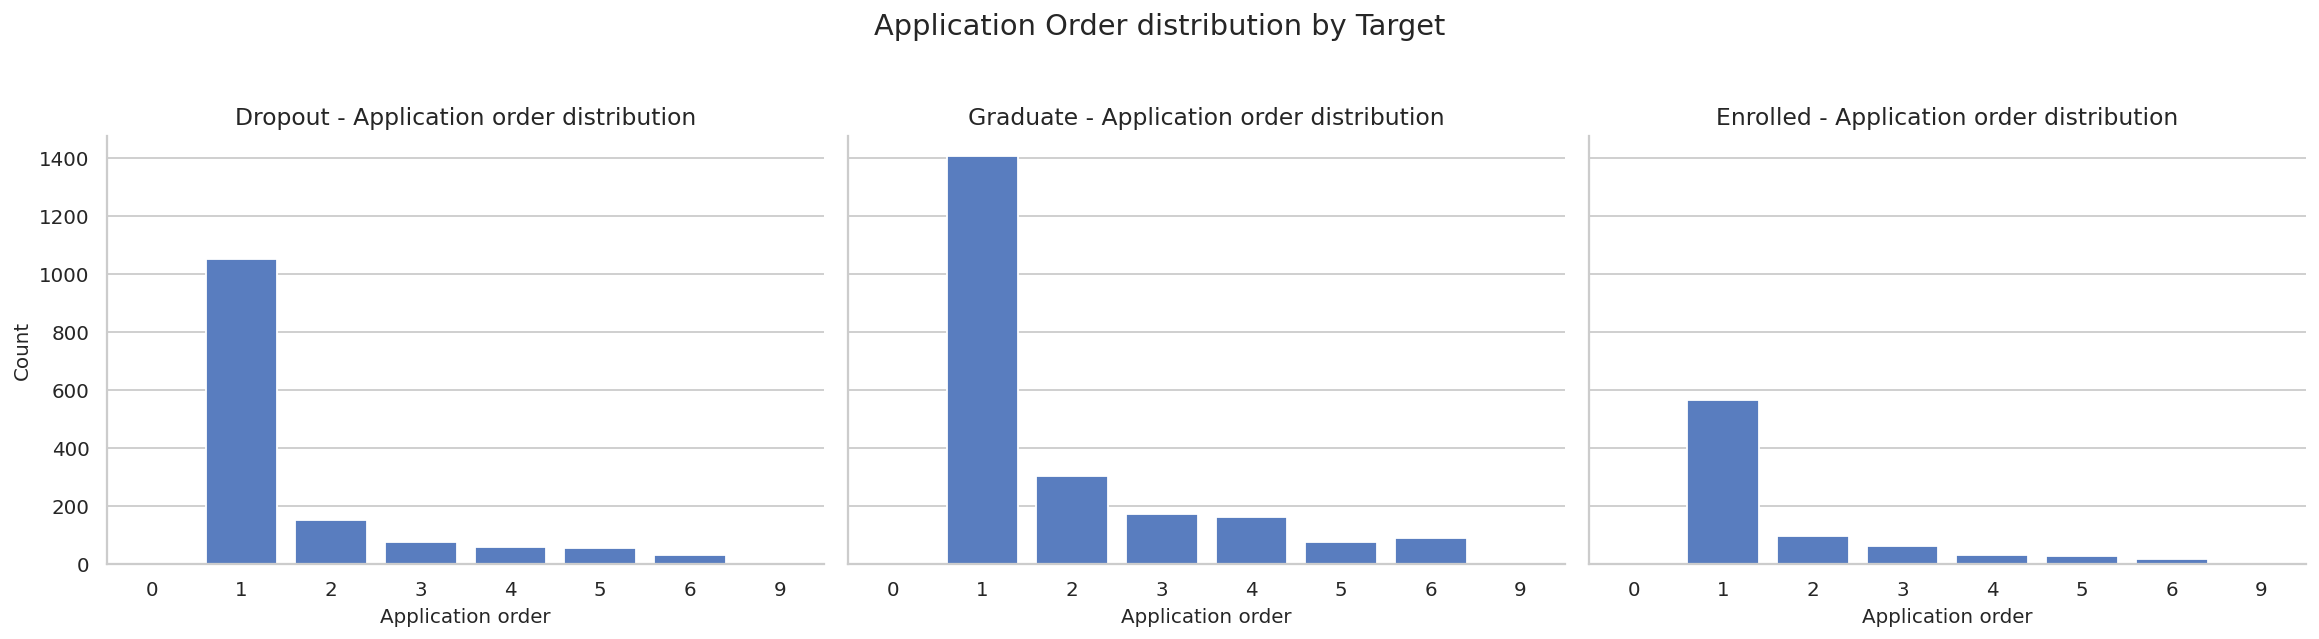

In [7]:

# df['Application order'] = df['Application order'].astype(str)
df = X.join(y)
targets = ['Dropout', 'Graduate', 'Enrolled']
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# If Application order is numeric-like, one can sort as ints
try:
    order_values = sorted(df['Application order'].dropna().unique(), key=lambda x: int(x))
except:
    order_values = sorted(df['Application order'].dropna().unique())

for ax, tgt in zip(axes, targets):
    subset = df[df['Target'] == tgt]
    if subset.empty:
        ax.text(0.5, 0.5, f"No data for {tgt}", ha='center', va='center')
        ax.set_title(tgt)
        continue
    sns.countplot(
        data=subset,
        x='Application order',
        order=order_values,
        ax=ax,
    )
    ax.set_title(f"{tgt} - Application order distribution")
    ax.set_xlabel("Application order")
    ax.set_ylabel("Count")

fig.suptitle("Application Order distribution by Target", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()